<a href="https://colab.research.google.com/github/slwilliams055/wrangling/blob/main/HW2_Wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!git clone https://github.com/slwilliams055/wrangling.git
!ls wrangling/assignment/data
import pandas as pd
import numpy as np

fatal: destination path 'wrangling' already exists and is not an empty directory.
airbnb_hw.csv  college_completion.csv  mn_police_use_of_force.csv
CBO_data.pdf   justice_data.parquet    unemployment.xlsx


# Question 1, Part 1

In [21]:
import pandas as pd
import numpy as np
airbnb = pd.read_csv("wrangling/assignment/data/airbnb_hw.csv")
print((airbnb).dtypes, '\n')
print(airbnb['Price'].value_counts(dropna=False))
#removes commas
airbnb['Price_clean'] = (
    airbnb['Price']
    .str.replace(',', '', regex=False)
    .astype(float)
)
#converts object to numeric so they are actually NaN
airbnb['Price'] = pd.to_numeric(airbnb['Price'], errors='coerce')
#dummy var
airbnb['Price_clean_na'] = airbnb['Price_clean'].isna()
print("After cleaning:\n", airbnb['Price_clean'].describe())
print("Total missing prices:", airbnb['Price_clean_na'].sum())
print("Proportion missing:", airbnb['Price_clean_na'].mean())
# there were 0 missing values

Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

Price
150    1481
100    1207
200    1059
125     889
75      873
       ... 
472       1
454       1
328       1
396       1
291       1
Name: count, Length: 511, dtype: int64
After cleaning:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_clean, dtype: float64
Total missing prices: 0
Proportion missing: 0.0


To clean this data, I removed the commas in the numbers over 999. I also created a dummy variable to make all the blank values nan. Since there were no nan values I did not have to impute. There were 0 missing values

# Question 1, Part 2


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
mn = pd.read_csv("wrangling/assignment/data/mn_police_use_of_force.csv")
print(mn['subject_injury'].value_counts(dropna=False))

mn['subject_injury_nan'] = mn['subject_injury'].isnull() #creates a dummy missing variable to put all the missing values
print('After coercion: \n', mn['subject_injury'].describe(),'\n') # Describe the numeric variable
print('Total Missings: \n', sum(mn['subject_injury_nan']),'\n') # #9848 are missing this is ~3/4ths of the data (76%)
# this tells me that there are only Yes, No, and NaN as values, which means it is standard
# I  don't like the NaN's but technically this is clean and NaN doesn't mean yes or no but just that we dont know.

# Calculate missing proportion
missing_count = mn['subject_injury'].isna().sum()
total_count = len(mn)
missing_prop = missing_count / total_count
print('Missing Proportion: \n', missing_prop,'\n') # #9848 are missing this is ~3/4ths of the data (76%)
# this means that ~76% of values are missing, which is problematic because it is a majority of the data.

# now cross tabulate
# looking to see if NaNs are concentrated in a certain force type
pd.crosstab(
    mn['subject_injury'],
    mn['force_type'],
    dropna=False
)
# this tells you what proportion of Yes, No, and NaN fall in what force_type.

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
After coercion: 
 count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object 

Total Missings: 
 9848 

Missing Proportion: 
 0.7619342359767892 



force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


  This shows that about 76% of the subject_inquiry valeus are missing. This is problematic and concerning because this means that injury outcomes are unavailable for the majority of these incidents. This suggests that for low-severity type of forces that subject inquiry data is always missing. For more aggressive force types such as firearms, there is never subject injury data missing. There is also no data missing for less lethal projectile. Moderate force types show up in the middle.

# Question 1, Part 3

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
pretrial = pd.read_csv(url,low_memory=False) # Pandas downloads and loads the .csv file for you
print(pretrial['WhetherDefendantWasReleasedPretrial'].unique(),'\n')
print(pretrial['WhetherDefendantWasReleasedPretrial'].head(20))
# Cleaning the data
pretrial['WhetherDefendantWasReleasedPretrial'] = pretrial['WhetherDefendantWasReleasedPretrial'].replace(9, np.nan)

# create dummy var
pretrial['WhetherDefendantWasReleasedPretrial_nan'] = pretrial['WhetherDefendantWasReleasedPretrial'].isnull()
print('After coercion: \n', pretrial['WhetherDefendantWasReleasedPretrial'].describe(),'\n') # Describe the numeric variable
print('Total Missings: \n', sum(pretrial['WhetherDefendantWasReleasedPretrial_nan']),'\n')
pretrial['WhetherDefendantWasReleasedPretrial_clean'] = pretrial['WhetherDefendantWasReleasedPretrial'].replace({
    0: 'No',
    1: 'Yes'
})


[9 0 1] 

0     9
1     0
2     0
3     0
4     1
5     0
6     1
7     1
8     0
9     1
10    1
11    0
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
Name: WhetherDefendantWasReleasedPretrial, dtype: int64
After coercion: 
 count    22955.000000
mean         0.834415
std          0.371716
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: WhetherDefendantWasReleasedPretrial, dtype: float64 

Total Missings: 
 31 



To clean this data, I was able to see that the unique values were 0,1, and 9. Because of this, we know that 9 means data is missing. I converted each 9 into a nan value to clean the data. I then counted the numner of missing values (31) in the "Whether DefendantWasReleasedPretrial" column. The 0's and 1's represent no and yes respectively.

# Question 1, Part 4

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
pretrial = pd.read_csv(url,low_memory=False)
print(pretrial['ImposedSentenceAllChargeInContactEvent'].value_counts(dropna=False))
print(pretrial['ImposedSentenceAllChargeInContactEvent'].unique(),'\n')

# convert to numeric
pretrial['ImposedSentenceAllChargeInContactEvent_clean'] = pd.to_numeric(pretrial['ImposedSentenceAllChargeInContactEvent'], errors='coerce')

#
pretrial.loc[
    pretrial['SentenceTypeAllChargesAtConvictionInContactEvent'] == 4,
    'ImposedSentenceAllChargeInContactEvent'
] = 'No sentence imposed'

#now that its numeric blank values are NaN
pretrial['ImposedSentenceAllChargeInContactEvent_nan'] = pretrial['ImposedSentenceAllChargeInContactEvent_clean'].isnull() #creates a dummy missing variable to put all the missing values
print('After coercion: \n', pretrial['ImposedSentenceAllChargeInContactEvent'].describe(),'\n') # Describe the numeric variable
print('Total Missings: \n', sum(pretrial['ImposedSentenceAllChargeInContactEvent_nan']),'\n')
print('Proportion missing:', pretrial['ImposedSentenceAllChargeInContactEvent_nan'].mean())

ImposedSentenceAllChargeInContactEvent
                    9053
0                   4953
12                  1404
.985626283367556    1051
6                    809
                    ... 
11.9055441478439       1
35.0061601642711       1
46.6242299794661       1
81.0225872689938       1
202                    1
Name: count, Length: 484, dtype: int64
[' ' '60' '12' '.985626283367556' '36' '6' '24' '5.91375770020534' '120'
 '72' '11.9917864476386' '0' '2.95687885010267' '84' '108' '300' '240'
 '180' '4' '96' '2' '54' '.328542094455852' '44' '5' '115' '132' '48'
 '258' '34' '76' '.164271047227926' '.131416837782341' '111' '9' '3'
 '1.97125256673511' '36.9856262833676' '.0657084188911704'
 '35.4928131416838' '106.492813141684' '8' '35' '18.3141683778234' '480'
 '32' '93' '234' '732' '1.16427104722793' '4.6570841889117' '21' '7'
 '4.49281314168378' '18' '600' '43.1642710472279' '179' '52' '30' '20'
 '192' '702' '14' '55' '53' '11.9055441478439' '114' '35.0061601642711'
 '68' '.657084188911

In order to clean this variable, it was important to understand context. A blank entry did not mean the same thing in all cases. A sentence type 4 likely corresponds with no sentence imposed, so I changed the blank to reflect that. In cases of a sentence type of 9, it likely indicated a missing value. I changed the sentence in this case to nan

# Question 2

                  Date    Year        Type        Country  \
0  2025-01-11 00:00:00  2025.0    Provoked            USA   
1  2025-01-02 00:00:00  2025.0  Unprovoked  New Caledonia   
2  2025-01-02 00:00:00  2025.0  Unprovoked      Australia   
3  2024-12-29 00:00:00  2024.0  Unprovoked          Egypt   
4  2024-12-29 00:00:00  2024.0  Unprovoked          Egypt   

                 State                                 Location      Activity  \
0               Hawaii            Off Haleiwa Boat Harbour Oahu        Diving   
1         Grande Terre              Islet of Kendek near Koumac  Spearfishing   
2      South Australia  Granites Beach near Westall Streaky Bay       Surfing   
3  North of Marsa Alam                                  Red Sea  SCUBA Diving   
4  North of Marsa Alam                                  Red Sea  SCUBA Diving   

                                     Name Sex Age  ...  \
0  Male not stated was a dive tour worker   M  23  ...   
1                        Rober

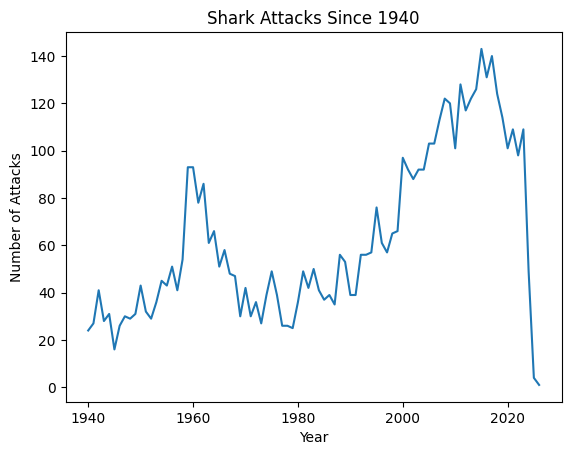

Total missing Ages: 2994
Proportion missing: 0.42832618025751074


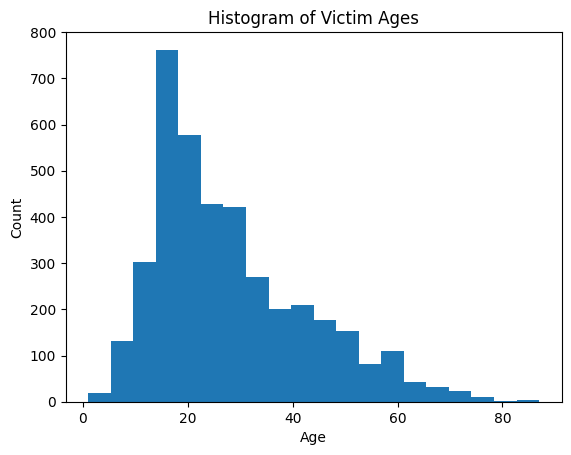

Sex
M          5614
F           792
Unknown     584
Name: count, dtype: int64
Proportion of victims who are male: 80.31%
Proportion of victims who are unprovoked: 0.7369098712446351
Type
Unprovoked    5151
Unknown       1200
Provoked       639
Name: count, dtype: int64
Fatal Y/N
N          4870
Y          1468
NaN         561
UNKNOWN      71
 N            7
F             4
M             3
Nq            1
n             1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64
Fatal Y/N
N          4879
Y          1469
Unknown     642
Name: count, dtype: int64
Type     Provoked   Unknown  Unprovoked
Sex                                    
F        0.039141  0.114899    0.845960
M        0.097613  0.134307    0.768080
Unknown  0.102740  0.607877    0.289384
Fatal Y/N          N   Unknown         Y
Type                                    
Provoked    0.953052  0.014085  0.032864
Unknown     0.374167  0.462500  0.163333
Unprovoked  0.741798  0.015143  0.2430

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the file and look at it
sharks = pd.read_excel("wrangling/data/GSAF5.xls")
print(sharks.head())
print(sharks.info())

# drop empty columns
sharks = sharks.dropna(axis=1, how='all')
sharks.info()

# cleaning the var
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce') # convert to numeric
sharks.loc[sharks['Year'] == 0, 'Year'] = np.nan
sharks['Year_nan'] = sharks['Year'].isna() # dummy

print("Total missing years:", sharks['Year_nan'].sum())
print("Proportion missing:", sharks['Year_nan'].mean())

# figure out the actual range
#print(sharks['Year'].desribe())
sharks_since_1940 = sharks[sharks['Year'] >= 1940] # filter from 1940
attacks_by_year = sharks_since_1940.groupby('Year').size()

# seeing if they are increasing over time
attacks_by_year.plot(kind='line')
plt.title("Shark Attacks Since 1940")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

# clean age var
sharks['Age'].unique()[:50]
# want to remove things like 60+, middle age, ?,nan

sharks['Age_nan'] = sharks['Age'].isnull()
sharks['Age'].apply(type).value_counts()
sharks['Age'] = sharks['Age'].astype(str).str.extract(r'(\d+)', expand=False)
sharks['Age'] = pd.to_numeric(sharks['Age'], errors='coerce')
sharks['Age'] = sharks['Age'].astype('Int64')
#print('After cleaning Age:\n', sharks['Age'].describe())
print('Total missing Ages:', sharks['Age_nan'].sum())
print('Proportion missing:', sharks['Age_nan'].mean())

# histogram
plt.hist(sharks['Age'].dropna(), bins=20)
plt.title("Histogram of Victim Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# clean sex variable
sharks['Sex'] = sharks['Sex'].astype(str).str.strip().str.upper()
sharks['Sex'] = sharks['Sex'].replace(['LLI','', ' ', 'MIL', 'N/A', 'UNKNOWN', 'NA', 'NONE'], 'Unknown')

# Only keep 'M' and 'F', everything else becomes Unknown
sharks.loc[~sharks['Sex'].isin(['M', 'F', 'Unknown']), 'Sex'] = 'Unknown'
print(sharks['Sex'].value_counts())

# proportion
prop_male = (sharks['Sex'] == 'M').mean()
male_count = (sharks['Sex'] == 'M').sum()
total = sharks['Sex'].notna().sum()
print(f'Proportion of victims who are male: {prop_male:.2%}')


# Clean TYPE var
sharks['Type'] = sharks['Type'].astype(str)
# Replace blanks  with 'Unknown'
sharks['Type'] = sharks['Type'].replace(['', ' ', 'nan', 'None'], 'Unknown')
sharks['Type'] = sharks['Type'].replace(['Questionable'], 'Unknown')

# Unprovoked
sharks.loc[sharks['Type'].str.contains('Unprovoked', na=False), 'Type'] = 'Unprovoked'
# Provoked
sharks.loc[sharks['Type'].str.contains('Provoked', na=False), 'Type'] = 'Provoked'
# Everything else becomes Unknown
sharks.loc[~sharks['Type'].isin(['Provoked', 'Unprovoked', 'Unknown']), 'Type'] = 'Unknown'

# proportion
prop_unprov = (sharks['Type'] == 'Unprovoked').mean()
print(f'Proportion of victims who are unprovoked:', prop_unprov)
# Check
print(sharks['Type'].value_counts())

# CLEAN FATAL
print(sharks['Fatal Y/N'].value_counts(dropna=False))
sharks['Fatal Y/N'] = sharks['Fatal Y/N'].astype(str).str.strip().str.title()
# replace blanks, etc.
sharks['Fatal Y/N'] = sharks['Fatal Y/N'].replace(['', ' ', 'None', 'nan'], 'Unknown')

# map valid types and everything else becomes unknown
valid_types = ['Y', 'N','Unknown']
sharks['Fatal Y/N'] = sharks['Fatal Y/N'].where(sharks['Fatal Y/N'].isin(valid_types), other="Unknown")
print(sharks['Fatal Y/N'].value_counts(dropna=False))

## 8 -
# Are sharks more likely to launch unprovoked attacks on men or women?:  P(Unprovoked | Sex = M) vs P(Unprovoked | Sex = F)
print(pd.crosstab(sharks['Sex'], sharks['Type'], normalize='index'))

# Is the attack more or less likely to be fatal when the attack is provoked or unprovoked?
print(pd.crosstab(sharks['Type'], sharks['Fatal Y/N'], normalize='index'))

#  Is it more or less likely to be fatal when the victim is male or female?
print(pd.crosstab(sharks['Sex'], sharks['Fatal Y/N'], normalize='index'))

## 9
#What proportion of attacks appear to be by white sharks?
sharks['Species '] = sharks['Species '].astype(str).str.lower()

# Split each species string into a list of words
sharks['Species_clean'] = sharks['Species '].str.split()  # e.g., 'white shark' -> ['white', 'shark']

# Check if 'white' is in the list of words for each row
sharks['White_shark'] = sharks['Species_clean'].apply(lambda x: 'white' in x)

# Proportion of attacks by white sharks
prop_white = sharks['White_shark'].mean()
print("Proportion of attacks by white sharks:", prop_white)

Proportion of attacks by white sharks: 0.10085836909871244

I cleaned the year variable by making anything that was nan into a dummy variable. There were 0 values that reflected BC time periods and I filtered those out as nans so that they would not be caught by the 1940 filter. The range of years goes from 0005 to 2026. There was a spike in attacks around 1960 and then a decrease until about 1980. The attacks rise to the highest peak around 2010 and continually decrease until 2026. I cleaned the age variable by dropping any nans and then made a histogram after dropping the nans temporarily.

**Are sharks more likely to launch unprovoked attacks on men or women?**
- Proportion of males: 0.8031
- Proportion of unprovoked attacks: 0.7369
- This tells me that sharks are more likely to launch unprovoked attacks on women (0.8459) than on men (0.7680).

**Is the attack more or less likely to be fatal when the attack is provoked or unprovoked?**
- The attack is much more likely to be fatal if unprovoked than if it is provoked. The proportions are 0.163 for unprovoked fatality and 0.032 for proboked.

**Is it more or less likely to be fatal when the victim is male or female?**
- It is more likely that the attack is fatal if the victim is male (0.2208) versus female (0.1515).

**How do you feel about sharks?**
- I already had fears about sharks but now with this information that states that not only are shark attacks more fatal if unprovoked, but they are also more fatal for females, my fear has grown. It is not a good feeling to know that even if you do not provoke a shark, you may still have a worse outcome than someone who did provoke it.

**What proportion of attacks appear to be by white sharks?**
- The proportion of attacks by white sharks is 0.1008.





Question 3

1. Read the abstract. What is this paper about?

    **ANSWER**: This paper is about why tidy data is necessary for proper use, as well as the tools you can use to do it. It explains not only how to tidy data but it also pushes for research to be done into ways to simplify and streamline it. The paper as a whole is about how to tidy data and why it is necessary in order to create data that is easier to work with.  
2. Read the introduction. What is the "tidy data standard" intended to accomplish?

    **ANSWER**: The tidy data standard is intended to facilitate exploration and analysis of the data and to simplify the development of data analysis tools that work well together. It is meant to create a consistent way to organize and structure datasets so that initial cleaning is easier and more standardized.
3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
    
    **ANSWER**: The first statement "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." means that a dataset is uniquely messy, in a similar manner that all families have their own norms and conflicts. When you tidy them up to standard, they become alike kind of how society views "healthy" family norms to be. Having a standard provides a set of criteria to tidy the data into a certain form. The second statement "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general." describes that within a dataset, it is easier to see how variables and observations are separated, but when context is introduced, it can be hard to define the two individually. Variables and observations can contain a lot of variety given a particular environment, which may make it difficult to actually distinguish them based on content, and further to understand and define what they mean.
4. Read Section 2.2. How does Wickham define values, variables, and observations?
    
    **ANSWER**: He defines a dataset as a collection of values that all belong to a variable and an observation. A variable contains all values that measure the same underlying attribute while an observation contains all values measured on the same unit across attributes. He explains that it is easy to figure out what are observations and what are variables but it can be difficult to define them in general because there can be different contexts as well as multiple levels of observations.

5. How is "Tidy data defined in section 2.3?

    **ANSWER**: Tidy data is defined in section 2.3 as a way of mapping the meaning of a dataset to its structure. He explains that the tidyness of a data set depends on how rows columns and tables are matched up with observations, variables, and types. In tidy data, each variable forms a column, each observation forms a row, and each type of observational unit forms a table.

6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset? Why, specifically, is table 11 messy but table 12 tidy and "molten"?


    **ANSWER**: The 5 most common problems with messy datasets are: column headers are values, multiple variables are stored in one column, variables are stored in both rows and columns, multiple types of observational units are stored in the same table, a single observational unit is stored in multiple tables.
    The data in table 4 is messy because variables are forming both the rows and colums, and column headers are value ranges instead of variable names.
    Melting a data set means to turn columns into rows. It is paramterised by a list of columns that are already variables (colvars), while the other columns are converted into two variables: column and value. The column variable contains repeated column headings and value contains the concatenated data values from the previously separate columns.

 7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

    **ANSWER**: Table 11 is messy because it shows variables in indivudal columns (id, year, month) spread across columns and across rows. In short, it contains variables stored in both rows and columns, which is defined as messy. Table 12a is mostly tidy because missing values were dropped and is molten because it was melted with colvars. Table 12b is completely tidy because the last final column, element, is melted. Table 12 contains one variable in each column, and each row represents a day's observation.

  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?
    
      **ANSWER**: The "chicken-and-egg" problem with focusing on tidy data is that tidy data is only as useful as the tools that work with it, but this causes tidy tools to be inextricable linked to tidy data. This could cause independently changing data structures or tools to not be helpful in improving workflow, because they are stuck in a local maxima. Wickham does not see tidy data as the final solution, so he hopes others will build on the framework to develop better data storage strategies and better tools. He hopes to incorporate methodologies from other fields like user-testing, ethnography, and talk-aloud protocols to improbe understanding of the cognitive side of data analysis. He wants to develop new strategies that may even ignore the underlying data representation in order to streamline the tidying process based on formats to optimize performance. It seems as though he wants to find a way to almost simplify the process, but still account for all of the necessary components of data tidying.